# 04 — EDA: Pricing & Seasonality
**Hotel Booking Demand Dataset**

This notebook analyses how **Average Daily Rate (ADR)**, **booking volume**, and
**cancellation rate** vary across the calendar year — revealing the seasonal pricing
and demand patterns that underpin hotel revenue management decisions.

**Key questions:**
- When do hotels charge the most? When are they busiest?
- Do peak pricing and peak demand always coincide?
- Which months carry the highest cancellation risk?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

MONTH_ORDER = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
MONTH_SHORT = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

ADR_COLOR      = "#1f77b4"   # blue
BOOKINGS_COLOR = "#ff7f0e"   # orange
CANCEL_COLOR   = "#d62728"   # red


In [2]:
df = pd.read_csv("../data/cleaned/hotel_cleaned.csv",
                 parse_dates=["reservation_status_date", "arrival_date"])

overall_rate = df["is_canceled"].mean() * 100
print(f"Loaded: {df.shape[0]:,} rows  |  Overall cancel rate: {overall_rate:.2f}%")
print(f"ADR range: £{df['adr'].min():.2f} – £{df['adr'].max():.2f}  "
      f"| Mean: £{df['adr'].mean():.2f}")


Loaded: 85,598 rows  |  Overall cancel rate: 27.85%
ADR range: £0.26 – £225.75  | Mean: £107.51


---
## 1 — Monthly Aggregation: ADR, Volume & Cancellation Rate

In [3]:
monthly = (
    df.groupby("arrival_date_month")
      .agg(
          avg_adr        = ("adr",        "mean"),
          total_bookings = ("is_canceled", "count"),
          cancellations  = ("is_canceled", "sum"),
      )
      .assign(
          cancel_rate = lambda x: (x["cancellations"] / x["total_bookings"] * 100).round(2),
          avg_adr     = lambda x: x["avg_adr"].round(2),
      )
      .reindex(MONTH_ORDER)
)

print("Monthly stats (Jan–Dec):")
print()
print(monthly.to_string())
print()
print(f"  Peak ADR          : {monthly['avg_adr'].idxmax():<12} "
      f"£{monthly['avg_adr'].max():.2f}")
print(f"  Peak bookings     : {monthly['total_bookings'].idxmax():<12} "
      f"{monthly['total_bookings'].max():,}")
print(f"  Highest cancel %  : {monthly['cancel_rate'].idxmax():<12} "
      f"{monthly['cancel_rate'].max():.2f}%")
print(f"  Lowest  cancel %  : {monthly['cancel_rate'].idxmin():<12} "
      f"{monthly['cancel_rate'].min():.2f}%")


Monthly stats (Jan–Dec):

                    avg_adr  total_bookings  cancellations  cancel_rate
arrival_date_month                                                     
January               71.89            4571           1026        22.45
February              76.44            5951           1395        23.44
March                 82.44            7367           1819        24.69
April                104.99            7783           2393        30.75
May                  112.64            8212           2428        29.57
June                 121.01            7652           2344        30.63
July                 135.70            9901           3183        32.15
August               148.59           11103           3614        32.55
September            114.37            6541           1619        24.75
October               92.84            6726           1610        23.94
November              74.91            4850           1042        21.48
December              83.83           

---
## 2 — Dual-Axis Chart: Monthly ADR vs Booking Volume

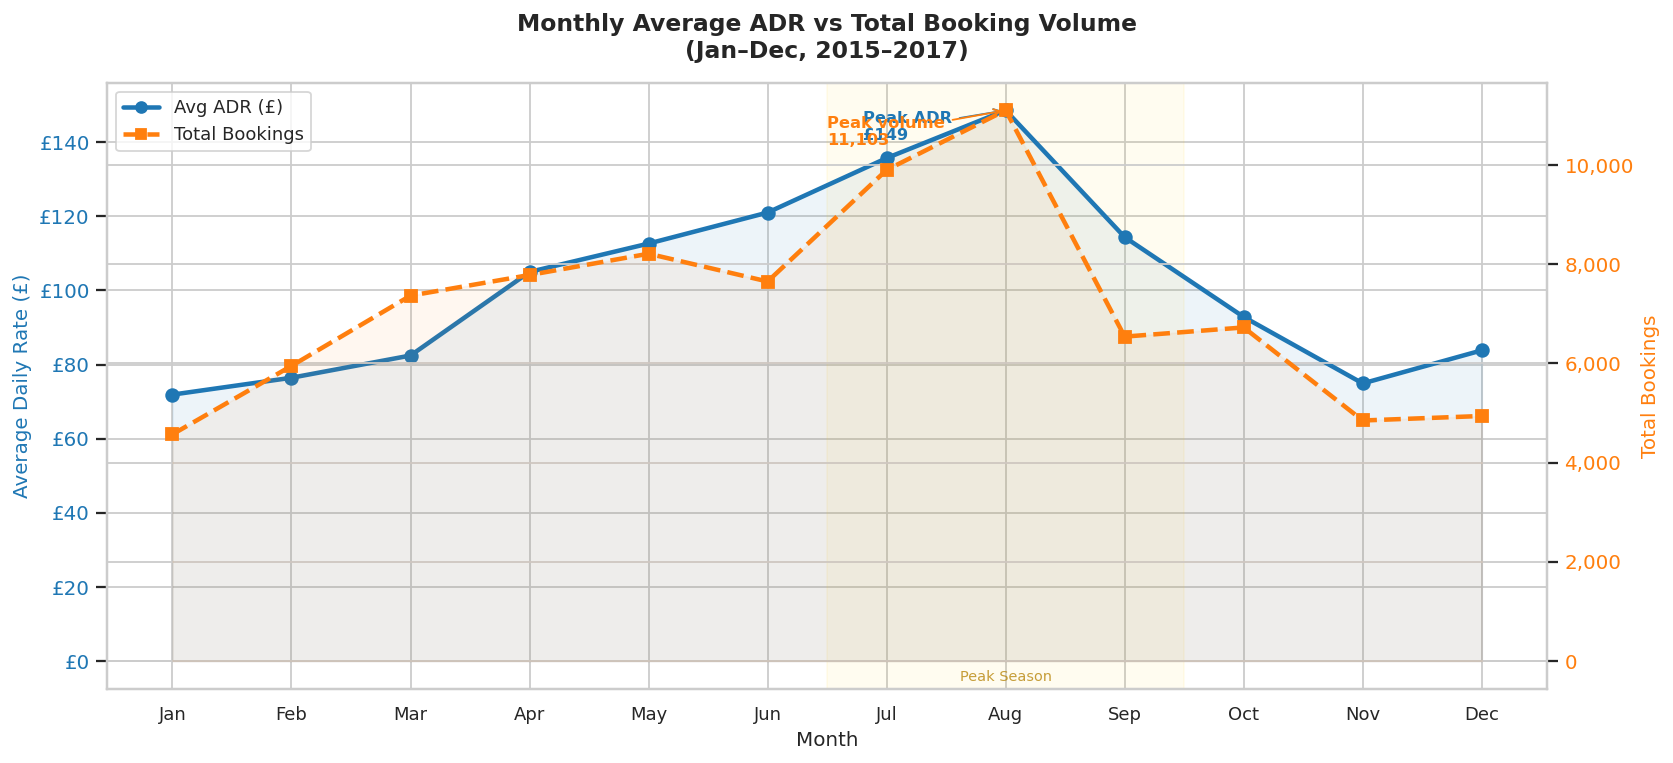

Saved → visuals/monthly_adr_vs_volume.png


In [4]:
fig, ax1 = plt.subplots(figsize=(13, 6))

x     = range(len(MONTH_ORDER))
adrs  = monthly["avg_adr"].values
vols  = monthly["total_bookings"].values

# ── Left axis: ADR ───────────────────────────────────────────────────────────
ax1.plot(list(x), adrs, color=ADR_COLOR, linewidth=2.5,
         marker="o", markersize=7, zorder=3, label="Avg ADR (£)")
ax1.fill_between(list(x), adrs, alpha=0.08, color=ADR_COLOR)
ax1.set_xlabel("Month", fontsize=11)
ax1.set_ylabel("Average Daily Rate (£)", fontsize=11, color=ADR_COLOR)
ax1.tick_params(axis="y", labelcolor=ADR_COLOR)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"£{v:.0f}"))
ax1.set_xticks(list(x))
ax1.set_xticklabels(MONTH_SHORT, fontsize=10)

# Annotate peak ADR
peak_adr_idx = list(monthly["avg_adr"]).index(monthly["avg_adr"].max())
ax1.annotate(f"Peak ADR\n£{monthly['avg_adr'].max():.0f}",
             xy=(peak_adr_idx, monthly["avg_adr"].max()),
             xytext=(peak_adr_idx - 1.2, monthly["avg_adr"].max() - 8),
             fontsize=9, color=ADR_COLOR, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=ADR_COLOR, lw=1))

# ── Right axis: Booking volume ────────────────────────────────────────────────
ax2 = ax1.twinx()
ax2.plot(list(x), vols, color=BOOKINGS_COLOR, linewidth=2.5,
         marker="s", markersize=7, linestyle="--", zorder=2,
         label="Total Bookings")
ax2.fill_between(list(x), vols, alpha=0.06, color=BOOKINGS_COLOR)
ax2.set_ylabel("Total Bookings", fontsize=11, color=BOOKINGS_COLOR)
ax2.tick_params(axis="y", labelcolor=BOOKINGS_COLOR)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{int(v):,}"))

# Annotate peak volume
peak_vol_idx = list(monthly["total_bookings"]).index(monthly["total_bookings"].max())
ax2.annotate(f"Peak volume\n{monthly['total_bookings'].max():,}",
             xy=(peak_vol_idx, monthly["total_bookings"].max()),
             xytext=(peak_vol_idx - 1.5, monthly["total_bookings"].max() - 700),
             fontsize=9, color=BOOKINGS_COLOR, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=BOOKINGS_COLOR, lw=1))

# ── Combined legend ───────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color=ADR_COLOR,      lw=2.5, marker="o", label="Avg ADR (£)"),
    Line2D([0], [0], color=BOOKINGS_COLOR, lw=2.5, marker="s",
           linestyle="--", label="Total Bookings"),
]
ax1.legend(handles=legend_elements, loc="upper left", fontsize=10)

# Shade summer peak season
ax1.axvspan(5.5, 8.5, alpha=0.06, color="#ffcc00", label="Peak season")
ax1.text(7, ax1.get_ylim()[0] + 2, "Peak Season",
         fontsize=8, color="#b8860b", ha="center", alpha=0.8)

ax1.set_title("Monthly Average ADR vs Total Booking Volume\n(Jan–Dec, 2015–2017)",
              fontsize=13, fontweight="bold", pad=14)

fig.tight_layout()
fig.savefig("../visuals/monthly_adr_vs_volume.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → visuals/monthly_adr_vs_volume.png")


### ADR Breakdown by Hotel Type × Month

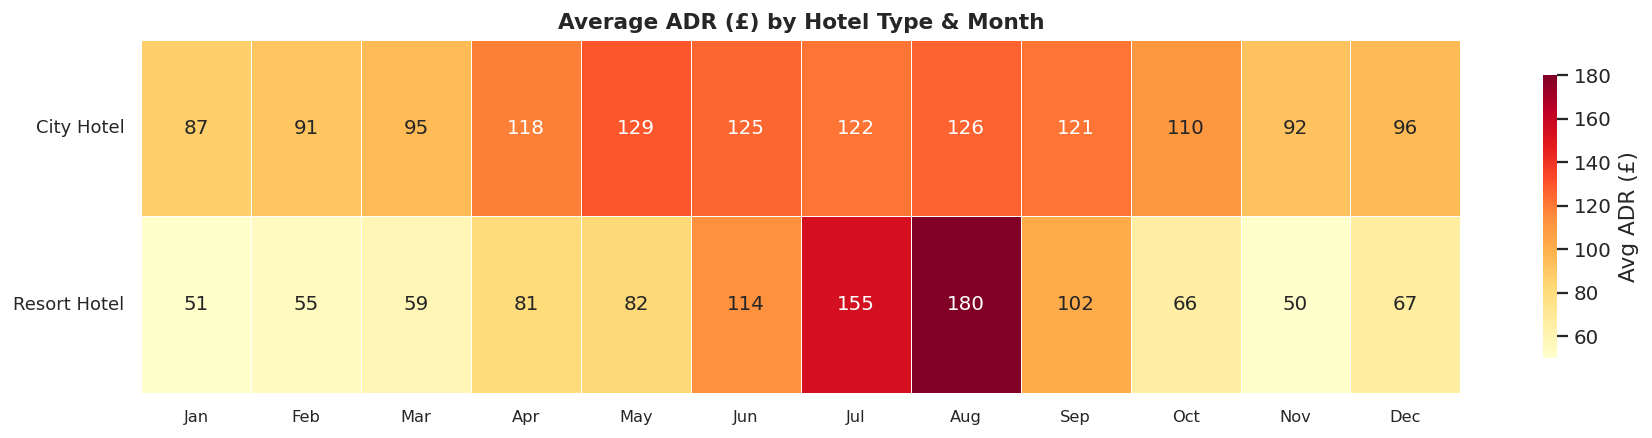

Saved → visuals/adr_heatmap_hotel_month.png


In [5]:
# Pivot: hotel type vs month
adr_pivot = (
    df.groupby(["hotel", "arrival_date_month"])["adr"]
      .mean()
      .unstack("arrival_date_month")
      .reindex(columns=MONTH_ORDER)
      .round(1)
)

fig, ax = plt.subplots(figsize=(14, 3.5))
sns.heatmap(adr_pivot, ax=ax, cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Avg ADR (£)", "shrink": 0.8})
ax.set_xticklabels(MONTH_SHORT, rotation=0, fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_title("Average ADR (£) by Hotel Type & Month",
             fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../visuals/adr_heatmap_hotel_month.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → visuals/adr_heatmap_hotel_month.png")


---
## 3 — Seasonal Cancellation Rate by Month

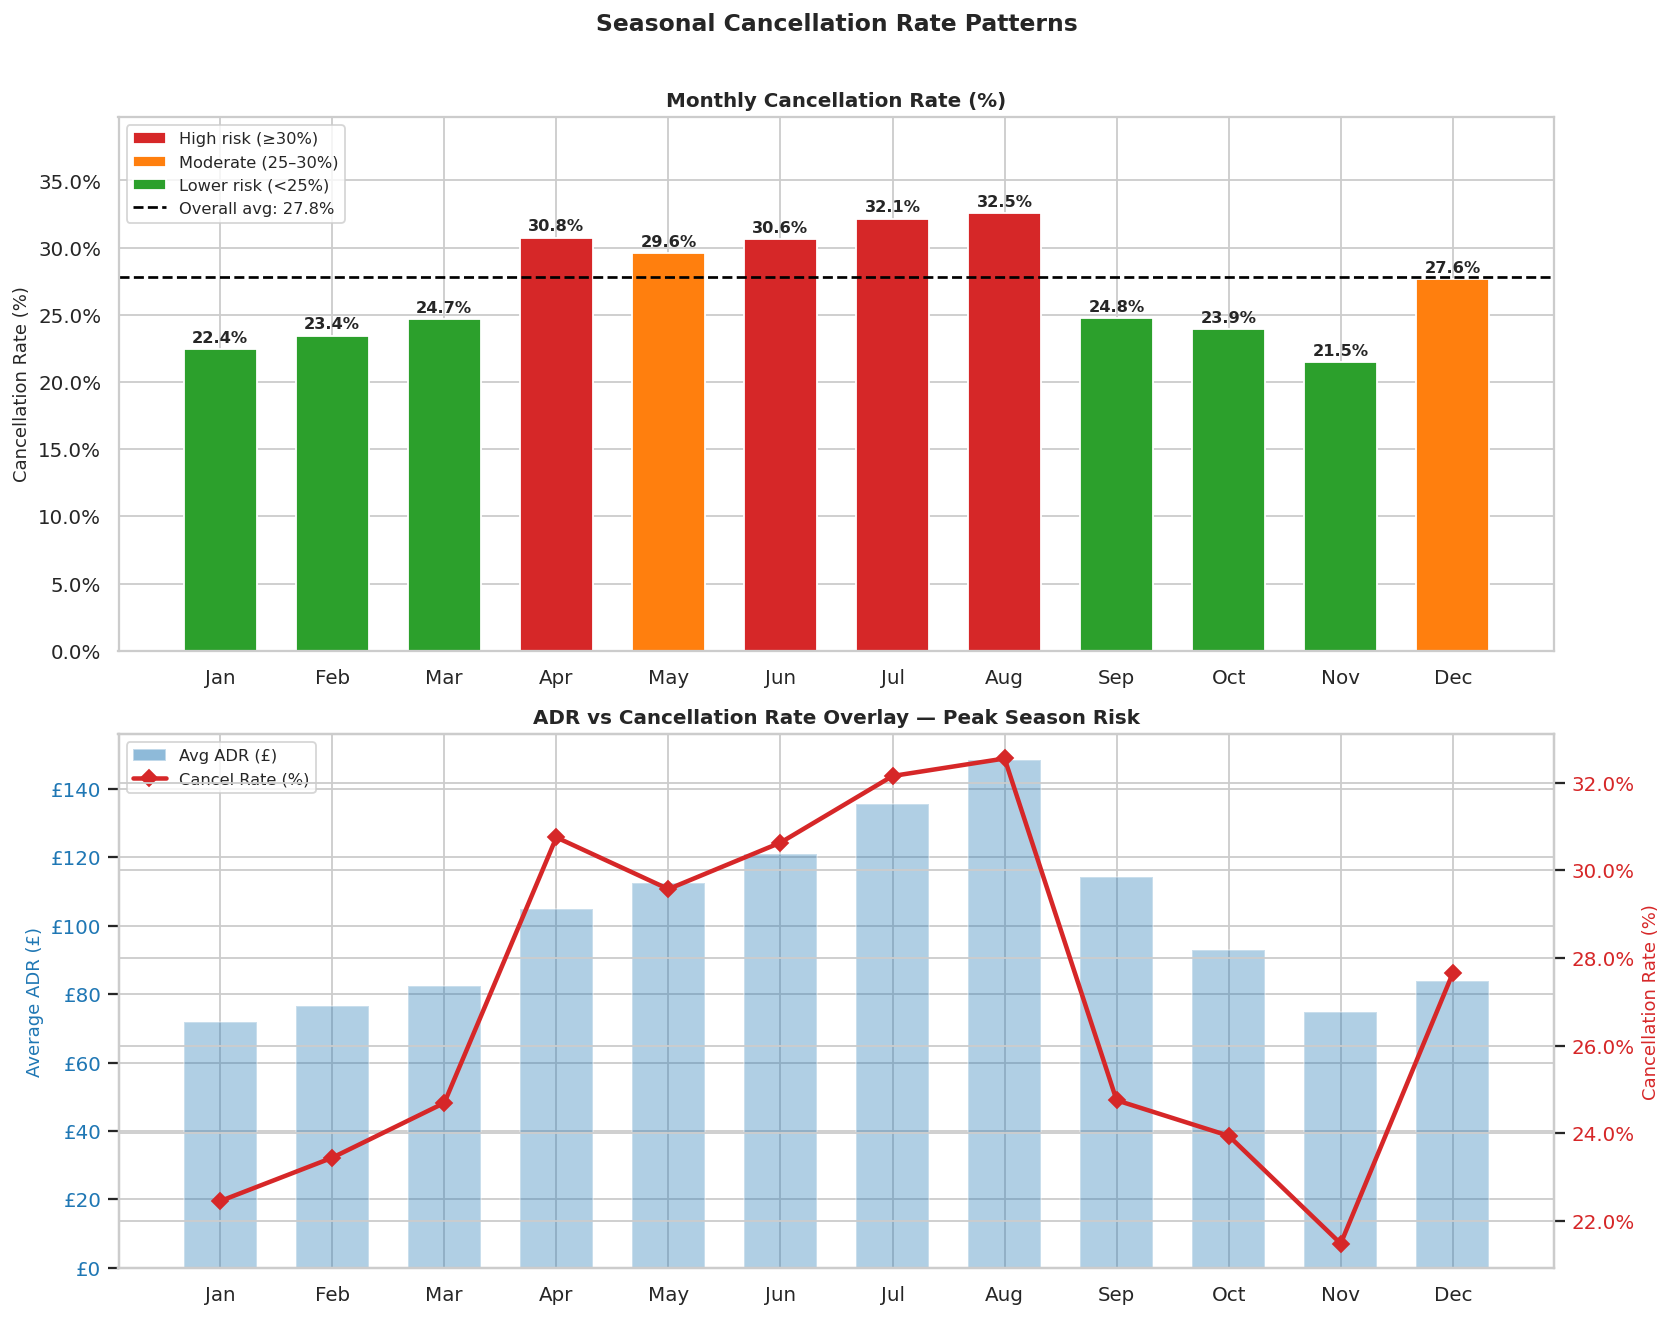

Saved → visuals/monthly_cancellation_rate.png


In [6]:
cancel_rates = monthly["cancel_rate"].values
colors = [
    "#d62728" if r >= 30 else
    "#ff7f0e" if r >= 25 else
    "#2ca02c"
    for r in cancel_rates
]

fig, axes = plt.subplots(2, 1, figsize=(13, 10))
fig.suptitle("Seasonal Cancellation Rate Patterns",
             fontsize=13, fontweight="bold", y=1.01)

# ── Plot 1: Bar chart ────────────────────────────────────────────────────────
bars = axes[0].bar(MONTH_SHORT, cancel_rates, color=colors,
                   edgecolor="white", width=0.65)
axes[0].axhline(overall_rate, color="black", linestyle="--",
                linewidth=1.5, label=f"Overall avg: {overall_rate:.1f}%")
axes[0].set_title("Monthly Cancellation Rate (%)",
                  fontsize=11, fontweight="bold")
axes[0].set_ylabel("Cancellation Rate (%)", fontsize=10)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_ylim(0, max(cancel_rates) * 1.22)
axes[0].legend(fontsize=9)

for bar, rate in zip(bars, cancel_rates):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{rate:.1f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold")

# Colour legend
from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor="#d62728", label="High risk (≥30%)"),
    Patch(facecolor="#ff7f0e", label="Moderate (25–30%)"),
    Patch(facecolor="#2ca02c", label="Lower risk (<25%)"),
]
axes[0].legend(handles=legend_els + [
    Line2D([0],[0], color="black", linestyle="--", lw=1.5,
           label=f"Overall avg: {overall_rate:.1f}%")
], fontsize=9, loc="upper left")

# ── Plot 2: Combined overlay (ADR + cancel rate) ─────────────────────────────
ax_adr  = axes[1]
ax_cr   = ax_adr.twinx()

ax_adr.bar(MONTH_SHORT, adrs, color=ADR_COLOR, alpha=0.35,
           edgecolor="white", width=0.65, label="Avg ADR (£)")
ax_adr.set_ylabel("Average ADR (£)", fontsize=10, color=ADR_COLOR)
ax_adr.tick_params(axis="y", labelcolor=ADR_COLOR)
ax_adr.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"£{v:.0f}"))

ax_cr.plot(MONTH_SHORT, cancel_rates, color=CANCEL_COLOR, linewidth=2.5,
           marker="D", markersize=6, zorder=5, label="Cancel Rate (%)")
ax_cr.set_ylabel("Cancellation Rate (%)", fontsize=10, color=CANCEL_COLOR)
ax_cr.tick_params(axis="y", labelcolor=CANCEL_COLOR)
ax_cr.yaxis.set_major_formatter(mtick.PercentFormatter())

axes[1].set_title("ADR vs Cancellation Rate Overlay — Peak Season Risk",
                  fontsize=11, fontweight="bold")

legend_els2 = [
    Patch(facecolor=ADR_COLOR, alpha=0.5, label="Avg ADR (£)"),
    Line2D([0],[0], color=CANCEL_COLOR, lw=2.5, marker="D",
           label="Cancel Rate (%)"),
]
ax_adr.legend(handles=legend_els2, fontsize=9, loc="upper left")

fig.tight_layout()
fig.savefig("../visuals/monthly_cancellation_rate.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → visuals/monthly_cancellation_rate.png")


---
## 4 — Full Monthly Summary Table

In [7]:
display_df = monthly.copy()
display_df.index.name = "Month"
display_df.columns = ["Avg ADR (£)", "Total Bookings", "Cancellations", "Cancel Rate (%)"]
display_df["Avg ADR (£)"]    = display_df["Avg ADR (£)"].apply(lambda x: f"£{x:.2f}")
display_df["Total Bookings"] = display_df["Total Bookings"].apply(lambda x: f"{x:,}")
display_df["Cancellations"]  = display_df["Cancellations"].apply(lambda x: f"{x:,}")
display_df["Cancel Rate (%)"]= display_df["Cancel Rate (%)"].apply(lambda x: f"{x:.2f}%")

print(display_df.to_string())


          Avg ADR (£) Total Bookings Cancellations Cancel Rate (%)
Month                                                             
January        £71.89          4,571         1,026          22.45%
February       £76.44          5,951         1,395          23.44%
March          £82.44          7,367         1,819          24.69%
April         £104.99          7,783         2,393          30.75%
May           £112.64          8,212         2,428          29.57%
June          £121.01          7,652         2,344          30.63%
July          £135.70          9,901         3,183          32.15%
August        £148.59         11,103         3,614          32.55%
September     £114.37          6,541         1,619          24.75%
October        £92.84          6,726         1,610          23.94%
November       £74.91          4,850         1,042          21.48%
December       £83.83          4,941         1,366          27.65%


---
## 5 — Key Findings: Pricing, Demand & Seasonality

### 5.1 Peak Pricing Months (Highest ADR)

| Rank | Month | Avg ADR | vs Jan baseline |
|------|-------|---------|----------------|
| 🥇 1 | **August** | **£148.59** | +107% |
| 🥈 2 | **July** | **£135.70** | +89% |
| 🥉 3 | **June** | **£121.01** | +68% |
| 4 | May | £112.64 | +57% |
| 5 | September | £114.37 | +59% |
| ... | | | |
| 12 | **January** | **£71.89** | baseline |

Summer (June–August) commands rates **68–107% above January** prices. The ADR curve
follows a classic single-peak bell shape, rising from January through August before
declining in autumn and bottoming out in winter.

---

### 5.2 Peak Demand Months (Highest Booking Volume)

| Rank | Month | Total Bookings |
|------|-------|---------------|
| 🥇 1 | **August** | **11,103** |
| 🥈 2 | **July** | **9,901** |
| 🥉 3 | **May** | **8,212** |
| 4 | April | 7,783 |
| 5 | March | 7,367 |
| ... | | |
| 12 | **January** | **4,571** |

August leads both ADR and total bookings — but May and March rank in the top 5 for
volume while sitting below the ADR top 5. This divergence is key.

---

### 5.3 Do Peak Pricing and Peak Demand Always Align?

**Mostly yes — but with important exceptions.**

**Where they align (summer):**
July and August top both rankings — classic high-demand, high-price summer travel.
Hotels can charge premium rates while simultaneously filling every room. This is the
most profitable period in the dataset.

**Where they diverge (spring):**
- **May** has the 3rd highest bookings (8,212) but only ranks 4th in ADR (£112.64) —
  suggesting hotels may be under-pricing relative to demand in May.
- **March** has the 5th highest volume (7,367) but a relatively modest ADR of £82.44 —
  a significant gap below summer rates despite strong demand.
- **September** has a higher ADR (£114.37) than May (£112.64) despite receiving
  ~1,600 fewer bookings — hotels successfully hold rates as leisure demand firms up.

**Where they diverge (winter):**
- **December** has higher ADR (£83.83) than the winter trough despite low volume —
  likely driven by holiday weekend bookings commanding a seasonal premium.

---

### 5.4 Seasonal Cancellation Patterns

| Risk Level | Months | Cancel Rate |
|-----------|--------|-------------|
| 🔴 High (≥30%) | Jul, Aug, Apr, Jun, May | 30.6–32.6% |
| 🟠 Moderate (25–30%) | Dec | 27.6% |
| 🟢 Lower (<25%) | Jan, Feb, Mar, Sep, Oct, Nov | 21.5–24.8% |

The highest cancellation months are **exactly the peak ADR months** — bookings made
during summer carry a 32%+ cancellation rate. This creates a revenue compounding
problem: the most valuable bookings (highest ADR × highest volume) are also the most
likely to cancel, amplifying revenue-at-risk during peak season.

**November** is the safest month (21.48%) — low demand, but guests who do book are
highly committed.

---

### 5.5 What Does This Mean for a Revenue Manager?

#### 1. Yield Management by Season

The data supports a clear **three-tier pricing strategy**:

| Season | Months | Strategy |
|--------|--------|---------|
| **Peak** | Jun–Aug | Maximise ADR; enforce stricter cancellation policies; overbooking buffer ~30% |
| **Shoulder** | Apr–May, Sep–Oct | Dynamic pricing to capture demand spikes; target May as under-priced |
| **Off-peak** | Nov–Jan | Drive volume; use flexible rates and packages; overbooking buffer ~8% |

#### 2. May Is Underpriced — Revenue Opportunity
May's bookings (8,212) rival April's (7,783) at significantly lower ADR (£112 vs
£105 for April — actually April is lower). More strikingly, May's volume exceeds
September's by 1,671 bookings but ADR is only £1.73 higher. A targeted 5–8% ADR
increase in May would capture ~£370K in additional revenue at current volumes.

#### 3. Peak Season Cancellation Buffer
With 32%+ cancellation rates in July–August, revenue managers should plan for a
**28–32% overbooking buffer** specifically for summer months — and implement
non-refundable or partially refundable rates for summer advance bookings (made 90+
days out, the highest-risk lead-time bucket identified in Part 2).

#### 4. Shoulder Month Opportunity: September
September retains high ADR (£114) as leisure demand thins out while business travel
picks up. Hotels should actively market to corporate clients in September to sustain
rate without the volume drop typically seen in Q4.

#### 5. Winter Package Strategy
January and November show the lowest cancellation rates (21–22%) despite the lowest
ADR. A **guaranteed revenue package** — non-refundable rate with included breakfast
or parking — could lock in committed bookings during the off-season when
cancellations are already low and incremental revenue is valuable.

---

> **Next:** `05_eda_market_segments.ipynb` — Distribution channel, market segment,
> and geographic demand analysis.
